Dataset Loaded Successfully!

First 5 Rows of Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  


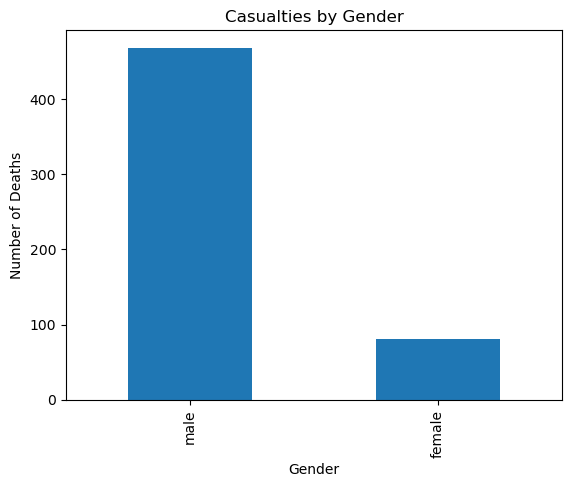

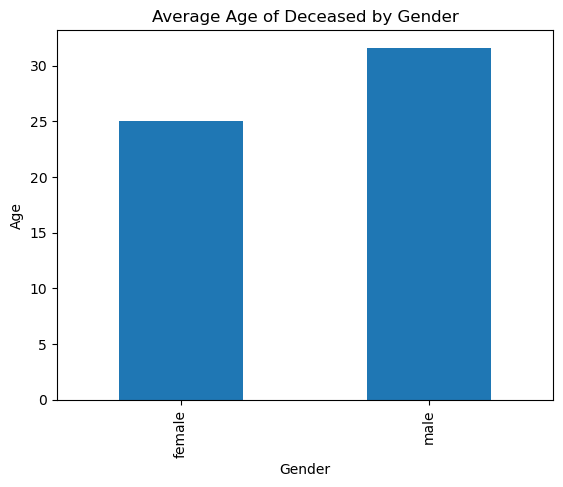

<Figure size 640x480 with 0 Axes>

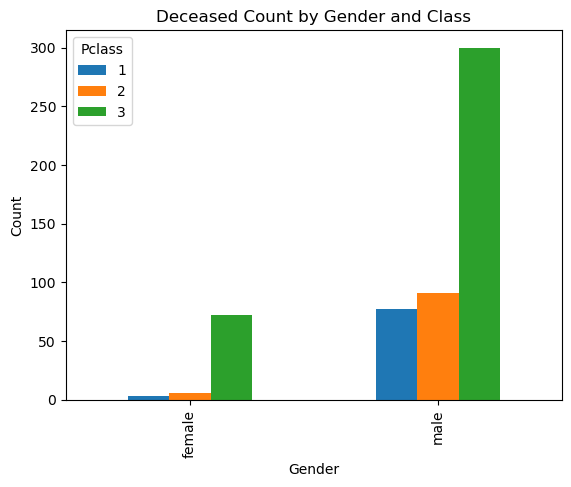

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def map_reduce_with_pandas(input_file):
    # ---------------- LOAD DATA ----------------
    df = pd.read_csv(input_file)

    print("Dataset Loaded Successfully!\n")
    print("First 5 Rows of Dataset:")
    print(df.head())

    # ---------------- MAP PHASE ----------------
    # Filter deceased passengers
    deceased = df[df['Survived'] == 0]

    # ---------------- REDUCE PHASE ----------------

    # 1. Gender-based casualty count (MAIN REQUIREMENT)
    gender_casualties = deceased['Sex'].value_counts()

    # 2. Average age of deceased by gender
    avg_age_by_gender = deceased.groupby('Sex')['Age'].mean()

    # 3. Class-wise deaths by gender
    class_by_gender = deceased.groupby('Sex')['Pclass'].value_counts()

    # 4. Survival comparison by gender (extra analysis)
    survival_by_gender = df.groupby('Sex')['Survived'].value_counts()

    # ---------------- OUTPUT ----------------
    print("\n===== Gender-based Casualties =====")
    print(gender_casualties)

    print("\n===== Average Age of Deceased by Gender =====")
    print(avg_age_by_gender)

    print("\n===== Deceased Count by Gender and Class =====")
    print(class_by_gender)

    print("\n===== Survival Analysis by Gender =====")
    print(survival_by_gender)

    # ---------------- VISUALIZATION ----------------

    # 1. Bar chart: Gender-based casualties
    plt.figure()
    gender_casualties.plot(kind='bar')
    plt.title("Casualties by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Number of Deaths")
    plt.show()

    # 2. Bar chart: Average age by gender
    plt.figure()
    avg_age_by_gender.plot(kind='bar')
    plt.title("Average Age of Deceased by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Age")
    plt.show()

    # 3. Bar chart: Female vs Male deaths by class
    plt.figure()
    class_by_gender.unstack().plot(kind='bar')
    plt.title("Deceased Count by Gender and Class")
    plt.xlabel("Gender")
    plt.ylabel("Count")
    plt.show()


# ---------------- RUN PROGRAM ----------------
input_file = "titanic_dataset.csv"   # Keep your CSV file in same folder
map_reduce_with_pandas(input_file)